In [10]:
%pip install numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import numpy as np
import matplotlib.pyplot as plt

### Carregamento dos dados do CSV

In [12]:
try:
# delimitador é virgula e pula a primeira linha (cabeçalho) com skiprows
    dados = np.loadtxt('dataset.csv', delimiter=',', skiprows=1)
except FileNotFoundError:
    print("Erro: Arquivo 'dataset.csv' não encontrada.")
    print("Por favor, crie o arquivo ou execute o script para gerá-lo.")
    exit()

In [13]:
# apenas visualizando os dados carregados do arquivo CSV
print(dados)

[[ 50. 150.]
 [ 60. 200.]
 [ 70. 250.]
 [ 80. 300.]
 [ 90. 350.]
 [100. 400.]
 [110. 420.]
 [120. 450.]
 [130. 470.]
 [140. 500.]]


In [14]:
### Separando os dados de X e Y
x = dados[:, 0]
y = dados[:, 1]

# visualiza os dados
print("x:", x)
print("y:", y)

print("\n Número de amostras: ", x.shape[0])

x: [ 50.  60.  70.  80.  90. 100. 110. 120. 130. 140.]
y: [150. 200. 250. 300. 350. 400. 420. 450. 470. 500.]

 Número de amostras:  10


In [15]:
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

print("x:", x)
print("")
print("y:", y)

x: [[ 50.]
 [ 60.]
 [ 70.]
 [ 80.]
 [ 90.]
 [100.]
 [110.]
 [120.]
 [130.]
 [140.]]

y: [[150.]
 [200.]
 [250.]
 [300.]
 [350.]
 [400.]
 [420.]
 [450.]
 [470.]
 [500.]]


### calculando "a" e "b"

In [16]:
# 2. calcular os coeficientes da regressão linear (a e b)
x_mean = np.mean(x)
y_mean = np.mean(y)

print("Media de x:", x_mean)
print("media de y:", y_mean)

Media de x: 95.0
media de y: 349.0


In [17]:
def predict(x_novo, _m, _b):
    """
    Prevê novos valores de y com base nos coeficientes da regressão
    Arg:
        x_novo: um numero ou array NumPy com os novos valores de x.
        m: O coeficiente angular (slope) do modelo.
        b: o intercepto do modelo.
    Returns:
        O(s) valor(es) de y previstos.        
    """
    return _m * x_novo + _b

coeficientes calculados a partir do CSV:
coeficiente angular (m): 3.9091
intercepto (b): -22.3636

 Equação da linha: y = 3.9091x + -22.3636

 coeficiente de determinação (R²): 0.9751
o modelo tem um bom ajuste aos dados.


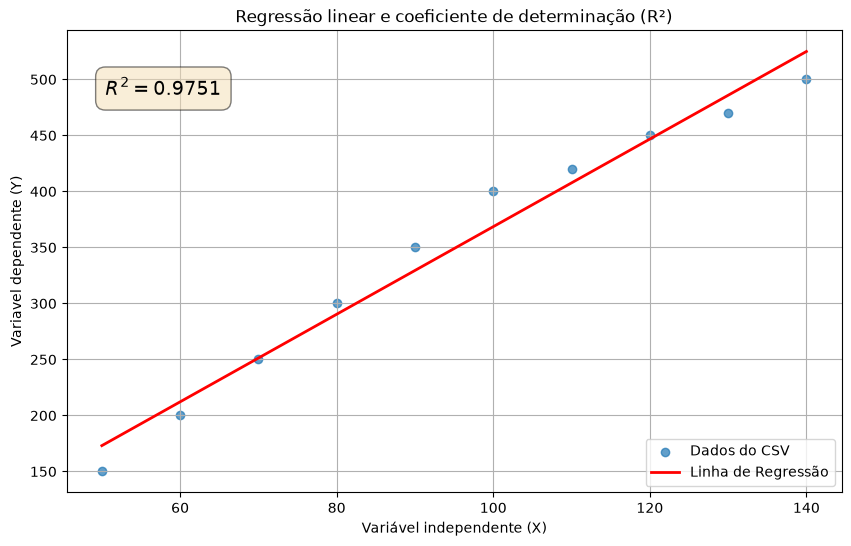

In [21]:
n = len(x)
numerador = np.sum((x - x_mean) * (y - y_mean))
denominador = np.sum((x - x_mean)**2)

m = numerador / denominador
b = y_mean - (m * x_mean)

# 3. Fazer as previsões do modelo
# Para cada valor de x, calculamos o y previsto (y) pela nossa linha.
y_pred = m * x + b

# 4. calcular o R-quadrado (R²) para avaliar o modelo
sqr = np.sum((y - y_pred)**2) # soma quadratica dos residos
sqt = np.sum((y - y_mean)**2) # soma quadratica total
r2 = 1 - (sqr / sqt)

# 5. imprimir os resultados
print(f"coeficientes calculados a partir do CSV:")
print(f"coeficiente angular (m): {m:.4f}")
print(f"intercepto (b): {b:.4f}")
print("\n Equação da linha: y = {:.4f}x + {:.4f}".format(m, b))
print(f"\n coeficiente de determinação (R²): {r2:.4f}")
if r2 > 0.75:
    print("o modelo tem um bom ajuste aos dados.")
elif r2 > 0.5:
    print("o modelo tem um ajuste moderado")
else:
    print("o modelo tem um ajuste fraco")  

# 6. criar a linha de regressão para visualização
x_line = np.array([x.min(), x.max()])
y_line = m * x_line + b

# Visualizar os resultados
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Dados do CSV', alpha=0.7)
plt.plot(x_line, y_line, color='red', linewidth=2, label='Linha de Regressão')

# Adiciona o valor R² ao gráfico para fácil visialização
plt.text(0.05, 0.9, f'$R^2 = {r2:.4f}$', transform=plt.gca().transAxes,
         fontsize=14, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.title("Regressão linear e coeficiente de determinação (R²)")
plt.xlabel('Variável independente (X)')
plt.ylabel('Variavel dependente (Y)')
plt.legend()
plt.grid(True)
plt.show()